<a href="https://colab.research.google.com/github/AsyrofiAnam/DeepLearning/blob/main/Klasifikasi_Gambar_Multilabel_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Library

In [1]:
# Standard Library
import os
# Data Science Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, multilabel_confusion_matrix, ConfusionMatrixDisplay
# Progress Bar
from tqdm import tqdm
# TensorFlow and Keras (Unified)
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, Flatten, Conv2D, MaxPooling2D,
                                     BatchNormalization, GlobalAveragePooling2D, Input)
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.metrics import AUC
from matplotlib.pyplot import imshow
from PIL import Image

#Instalasi dan Setup API Kaggle

In [2]:
!pip install -q kaggle

In [3]:
os.environ["KAGGLE_USERNAME"] = "fiin28"
os.environ["KAGGLE_KEY"] = "70a3c7c49b76b5262b742d519723ea8a"

#Download dan Ekstraksi Dataset dari Kaggle

In [4]:
!kaggle datasets download -d fiin28/datasetmultilabe-asyrofianam-202255202070

Dataset URL: https://www.kaggle.com/datasets/fiin28/datasetmultilabe-asyrofianam-202255202070
License(s): unknown


In [5]:
!unzip datasetmultilabe-asyrofianam-202255202070.zip

Archive:  datasetmultilabe-asyrofianam-202255202070.zip
  inflating: DatasetMultilabe_AsyrofiAnam_202255202070/Gambar001.jpg  
  inflating: DatasetMultilabe_AsyrofiAnam_202255202070/Gambar002.jpg  
  inflating: DatasetMultilabe_AsyrofiAnam_202255202070/Gambar003.jpg  
  inflating: DatasetMultilabe_AsyrofiAnam_202255202070/Gambar004.jpg  
  inflating: DatasetMultilabe_AsyrofiAnam_202255202070/Gambar005.jpg  
  inflating: DatasetMultilabe_AsyrofiAnam_202255202070/Gambar006.jpg  
  inflating: DatasetMultilabe_AsyrofiAnam_202255202070/Gambar007.jpg  
  inflating: DatasetMultilabe_AsyrofiAnam_202255202070/Gambar008.jpg  
  inflating: DatasetMultilabe_AsyrofiAnam_202255202070/Gambar009.jpg  
  inflating: DatasetMultilabe_AsyrofiAnam_202255202070/Gambar010.jpg  
  inflating: DatasetMultilabe_AsyrofiAnam_202255202070/Gambar011.jpg  
  inflating: DatasetMultilabe_AsyrofiAnam_202255202070/Gambar012.jpg  
  inflating: DatasetMultilabe_AsyrofiAnam_202255202070/Gambar013.jpg  
  inflating: DatasetM

#Load CSV dan Tampilkan Data Awal

In [6]:
df = pd.read_csv('/content/traindataset_AsyrofiAnam_202255202070.csv')
pd.set_option('display.max_columns', None)
df.head()

,Id,Object,Pensil,Penghapus,Penggaris,Jangka
0,Gambar001,"['Penghapus', 'Jangka']",0,1,0,1
1,Gambar002,"['Pensil', 'Jangka']",1,0,0,1
2,Gambar003,"['Pensil', 'Penghapus', 'Penggaris', 'Jangka']",1,1,1,1
3,Gambar004,"['Pensil', 'Penghapus', 'Penggaris', 'Jangka']",1,1,1,1
4,Gambar005,"['Pensil', 'Penghapus', 'Penggaris']",1,1,1,0


#Load dan Preprocessing Gambar

In [7]:
SIZE = 256
X_dataset = []
image_directory = '/content/DatasetMultilabe_AsyrofiAnam_202255202070'
for i in tqdm(range(df.shape[0])):
    img = image.load_img(image_directory + '/' + df['Id'][i]+'.jpg', target_size=(SIZE,SIZE,3))
    img = image.img_to_array(img)
    img = img/255.0
    X_dataset.append(img)

X = np.array(X_dataset)

100%|██████████| 300/300 [00:34<00:00,  8.78it/s]


Gambar150
['Pensil', 'Penghapus', 'Jangka']


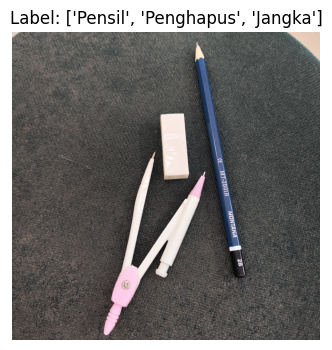

In [8]:
print(df['Id'][149])
print(df['Object'][149])
image_path = os.path.join(image_directory, df['Id'][149] + '.jpg')
img = Image.open(image_path)

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f"Label: {df['Object'][149]}")
plt.axis('off')
plt.show()

#Ekstraksi Label dan Pembagian Dataset

In [9]:
y = np.array(df.drop(['Id', 'Object'], axis=1))

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.10, random_state=20)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1111, random_state=20)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 240, Val: 30, Test: 30


#Arsitektur dan Kompilasi Model MobileNetV2

In [10]:
input_shape = (256, 256, 3)
num_classes = 4
multi_label = True

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output_activation = 'sigmoid' if multi_label else 'softmax'
loss_fn = 'binary_crossentropy' if multi_label else 'categorical_crossentropy'

output = Dense(num_classes, activation=output_activation)(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')])

model.summary()


<ipython-input-10-a4663aab1a03>:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

#Pelatihan Model

In [11]:
history = model.fit(X_train, y_train,
                    epochs=50,
                    validation_data=(X_val, y_val),
                    batch_size=32)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - auc: 0.5349 - loss: 0.6974 - val_auc: 0.8374 - val_loss: 0.4276
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - auc: 0.7982 - loss: 0.4564 - val_auc: 0.9114 - val_loss: 0.3608
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - auc: 0.8871 - loss: 0.3722 - val_auc: 0.9354 - val_loss: 0.2958
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - auc: 0.9283 - loss: 0.2911 - val_auc: 0.9490 - val_loss: 0.2710
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - auc: 0.9558 - loss: 0.2404 - val_auc: 0.9621 - val_loss: 0.2456
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - auc: 0.9727 - loss: 0.2140 - val_auc: 0.9699 - val_loss: 0.1971
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - auc: 0.9689 - loss: 0.1984 - val_auc: 0.9792 - val_loss: 0.1841
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - auc: 0.9755 - loss: 0.1825 - val_auc: 0.9799 - val_loss: 0.1646
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - auc: 0.9802 - loss: 0.1650 - 

#Visualisasi AUC dan Loss Selama Pelatihan

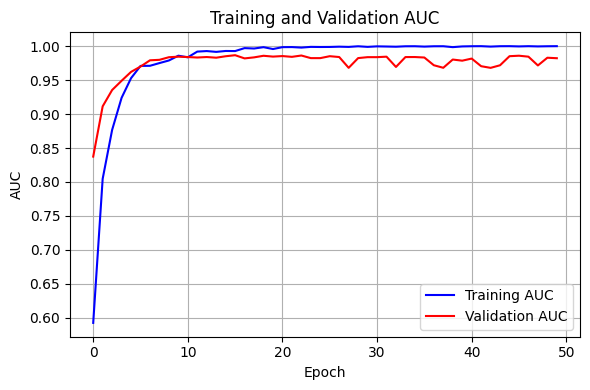

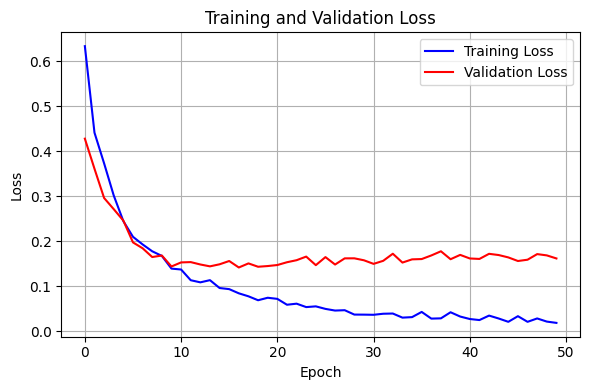

In [12]:
# Ambil data dari history untuk plotting
auc = history.history['auc']
val_auc = history.history['val_auc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(auc))

# Plot AUC
plt.figure(figsize=(6, 4))
plt.plot(epochs, auc, 'b', label='Training AUC')
plt.plot(epochs, val_auc, 'r', label='Validation AUC')
plt.title('Training and Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Loss
plt.figure(figsize=(6, 4))
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#Prediksi Gambar Tunggal

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Penghapus (0.997)
Jangka (0.994)
Pensil (0.00744)
Penggaris (0.000688)


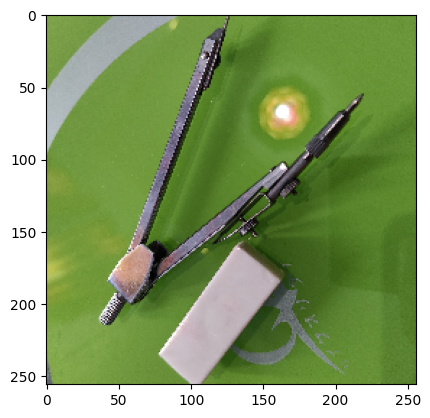

In [13]:
img = image.load_img('/content/DatasetMultilabe_AsyrofiAnam_202255202070/Gambar295.jpg', target_size=(SIZE,SIZE,3))

img = image.img_to_array(img)
img = img/255.
plt.imshow(img)
img = np.expand_dims(img, axis=0)

classes = np.array(df.columns[2:])
proba = model.predict(img)
sorted_categories = np.argsort(proba[0])[:-11:-1]

for i in range(4):
    print("{}".format(classes[sorted_categories[i]])+" ({:.3})".format(proba[0][sorted_categories[i]]))

#Evaluasi Model pada Data Test

In [14]:
loss, auc_score = model.evaluate(X_test, y_test)
print("AUC = ", (auc_score * 100.0), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - auc: 0.9798 - loss: 0.1822
AUC =  97.98136353492737 %


#Evaluasi Kinerja dan Confusion Matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
              precision    recall  f1-score   support

      Pensil       0.91      0.91      0.91        23
   Penghapus       0.85      1.00      0.92        23
   Penggaris       1.00      1.00      1.00        19
      Jangka       1.00      1.00      1.00        23

   micro avg       0.93      0.98      0.96        88
   macro avg       0.94      0.98      0.96        88
weighted avg       0.94      0.98      0.96        88
 samples avg       0.94      0.97      0.95        88



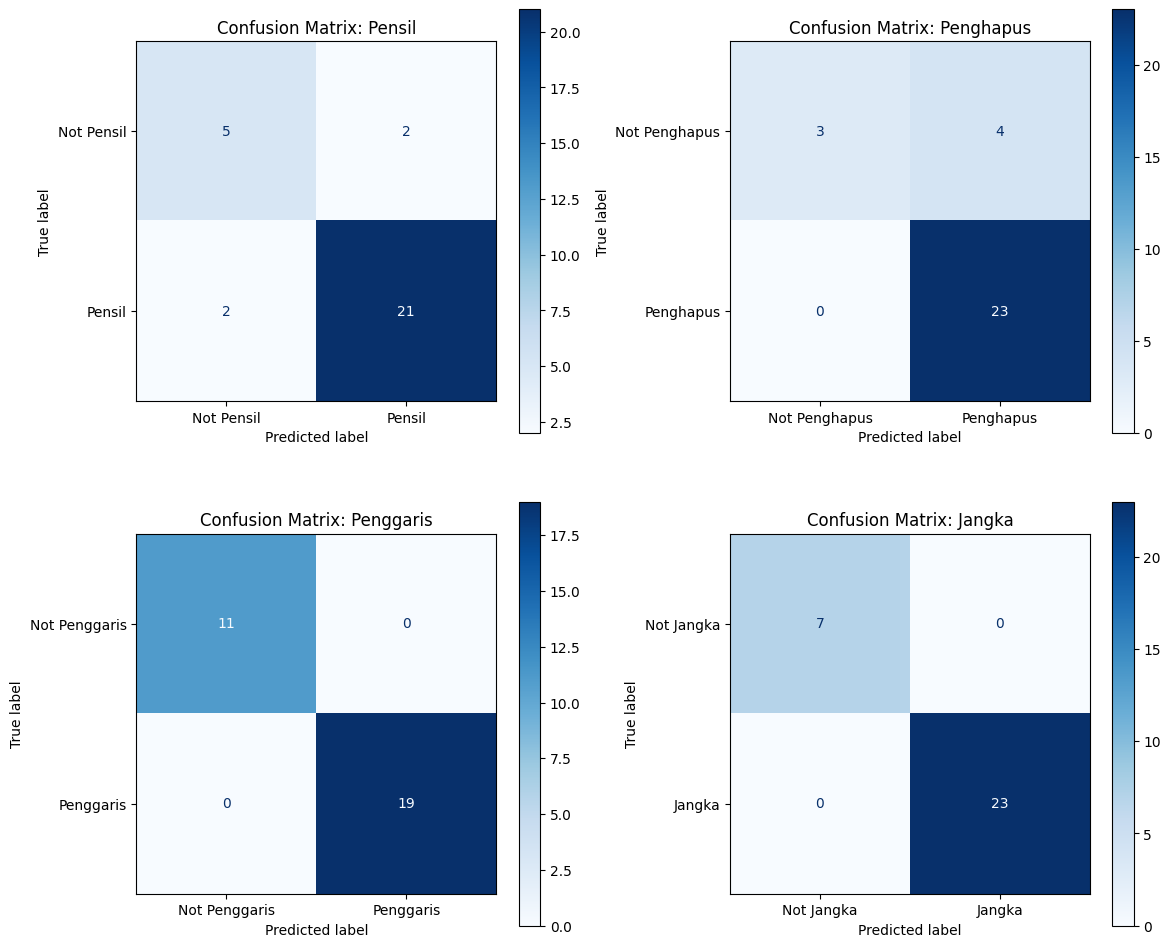

In [15]:
# Prediksi
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

# Laporan klasifikas
print(classification_report(y_test, y_pred_classes, target_names=df.columns[2:], zero_division=0))

# Plot Confusion Matrix untuk setiap label
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, label in enumerate(df.columns[2:]):
    cm = multilabel_confusion_matrix(y_test, y_pred_classes)[i]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f'Not {label}', label])
    disp.plot(ax=axes[i], values_format='d', cmap='Blues')
    axes[i].set_title(f'Confusion Matrix: {label}')

plt.tight_layout()
plt.show()